# P13 - Evaluation des modeles ML

Benchmark des modeles candidats sur les 3 cibles du projet.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GroupKFold, GroupShuffleSplit, cross_val_score

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
else:
    sys.path.insert(0, '../../src')

from p13.db import read_sql
from p13.ml.features import ALL_TARGETS, FEATURE_COLUMNS
from p13.ml.train import get_model_candidates

In [2]:
df = read_sql('SELECT * FROM ml_dataset_commune WHERE nb_eleves_maternelle IS NOT NULL')
df = df.dropna(subset=FEATURE_COLUMNS + ALL_TARGETS).copy()

if len(df) < 20:
    raise ValueError(f'Dataset trop petit pour benchmark robuste: {len(df)} lignes')

df.shape

(688, 17)

In [3]:
def metrics(y_true, y_pred):
    mape_mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100) if mape_mask.any() else 0.0
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'mape': mape
    }

## Métriques d'évaluation — définitions

Les 4 métriques calculées mesurent la qualité des prédictions sur le jeu de test (20% des données) :

| Métrique | Formule | Interprétation |
|---|---|---|
| **R²** (coefficient de détermination) | 1 − SS_res/SS_tot | Proportion de variance expliquée. **1.0 = parfait**, 0 = pas mieux que la moyenne, <0 = pire que la moyenne. Viser > 0.90. |
| **RMSE** (Root Mean Squared Error) | √(moyenne des (ŷ − y)²) | Erreur moyenne en **unité de la cible** (élèves ou classes). Pénalise fortement les grandes erreurs. |
| **MAE** (Mean Absolute Error) | moyenne de |ŷ − y| | Erreur absolue moyenne. Plus robuste aux outliers que le RMSE. |
| **MAPE** (Mean Absolute Percentage Error) | moyenne de |ŷ − y| / y × 100 | Erreur relative en %. Facilite la comparaison entre cibles d'échelles différentes. Attention : instable si y ≈ 0. |

> La **Cross-Validation R²** (cv_r2_mean) évalue la stabilité du modèle sur 5 sous-ensembles : un écart important entre R² test et cv_r2 signale du surapprentissage.

In [4]:
from sklearn.linear_model import Ridge
from p13.ml.feature_engineering import add_interaction_features, spatial_cross_validate
from p13.ml.features import FEATURE_COLUMNS_ENGINEERED, SPATIAL_GROUP_COLUMN
import json
from pathlib import Path

# Charger les alphas Ridge optimaux trouvés en 03_hyperparameter_tuning
models_dir = Path('/app/models') if Path('/app/models').exists() else Path('../../models')
best_ridge_alphas = json.loads((models_dir / 'best_ridge_alphas.json').read_text())

df_eng = add_interaction_features(df)
feature_cols = [c for c in FEATURE_COLUMNS_ENGINEERED if c in df_eng.columns]

rows = []
for target in ALL_TARGETS:
    df_t = df_eng.dropna(subset=feature_cols + [target])
    X = df_t[feature_cols].values
    y = df_t[target].values
    groups = df_t[SPATIAL_GROUP_COLUMN].values

    candidates = get_model_candidates()
    # Remplace le Ridge par défaut (alpha=1.0) par l'alpha tuné pour cette cible
    candidates['ridge'] = Ridge(alpha=best_ridge_alphas.get(target, 1.0))

    for model_name, model in candidates.items():
        spatial_res = spatial_cross_validate(model, X, y, groups, n_splits=5)
        rows.append({
            'target': target,
            'model': model_name,
            'train_r2': spatial_res['mean_train'],
            'test_r2': spatial_res['mean_test'],
            'test_std': spatial_res['std_test'],
            'overfit_gap': spatial_res['overfit_gap'],
        })

results = pd.DataFrame(rows).sort_values(['target', 'test_r2'], ascending=[True, False])
results

,target,model,train_r2,test_r2,test_std,overfit_gap
8,nb_classes,linear_regression,0.980290,0.916815,0.047183,0.063475
9,nb_classes,ridge,0.980146,0.915073,0.048969,0.065073
10,nb_classes,random_forest,0.984591,-3.318133,7.925836,4.302725
11,nb_classes,gradient_boosting,0.984602,-6.875658,15.054806,7.860260
5,nb_eleves_elementaire,ridge,0.985651,0.943911,0.037096,0.041740
4,nb_eleves_elementaire,linear_regression,0.985670,0.942507,0.037665,0.043162
7,nb_eleves_elementaire,gradient_boosting,0.990098,-0.648757,2.639242,1.638855
6,nb_eleves_elementaire,random_forest,0.990093,-2.203785,5.706471,3.193879
1,nb_eleves_maternelle,ridge,0.988727,0.916102,0.042554,0.072625
0,nb_eleves_maternelle,linear_regression,0.988744,0.915736,0.042814,0.073008


## Lecture du tableau de benchmark

Le tableau ci-dessus compare les 4 modèles sur les 3 cibles. Pour chaque cible, les lignes sont triées par R² décroissant (meilleur en haut).

**Comment lire les résultats :**

- Un R² > 0.98 sur un jeu de données aussi petit (quelques dizaines de communes) doit être interprété avec prudence : le modèle apprend bien mais le risque de surapprentissage est réel — vérifier le cv_r2.
- Le RMSE sur `nb_eleves_elementaire` sera naturellement plus élevé que sur `nb_classes` car les échelles sont différentes (centaines d'élèves vs dizaines de classes).
- **Régression linéaire et Ridge** servent de **baseline** : si un modèle plus complexe ne fait pas mieux, la relation est linéaire et le modèle simple est préférable (interprétabilité, rapidité).
- **Random Forest** et **Gradient Boosting** capturent les non-linéarités mais sont des boîtes noires — d'où l'intérêt des analyses SHAP du notebook 02.

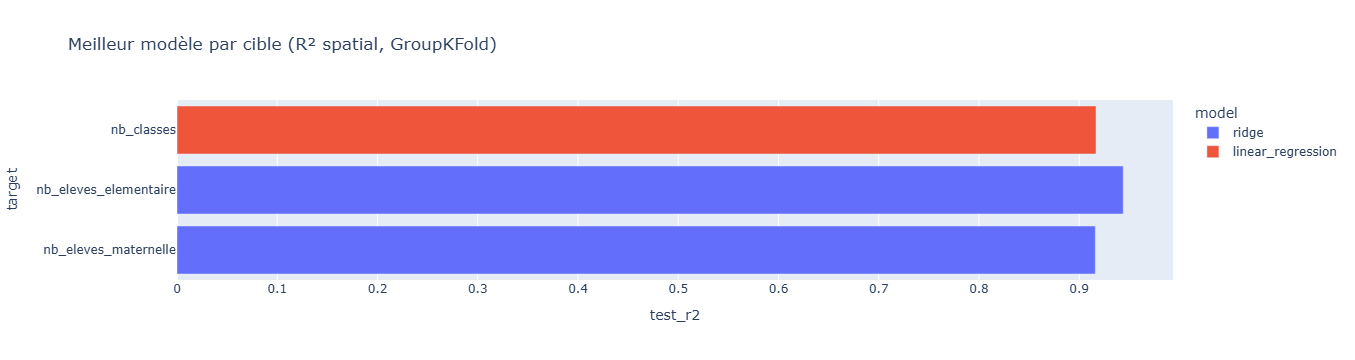

,target,model,train_r2,test_r2,test_std,overfit_gap
1,nb_eleves_maternelle,ridge,0.988727,0.916102,0.042554,0.072625
8,nb_classes,linear_regression,0.980290,0.916815,0.047183,0.063475
5,nb_eleves_elementaire,ridge,0.985651,0.943911,0.037096,0.041740


In [5]:
best = results.loc[results.groupby('target')['test_r2'].idxmax()].copy()
best = best.sort_values('test_r2', ascending=True)

fig = px.bar(
    best, x='test_r2', y='target', color='model',
    orientation='h', title='Meilleur modèle par cible (R² spatial, GroupKFold)'
)
fig.show()
best

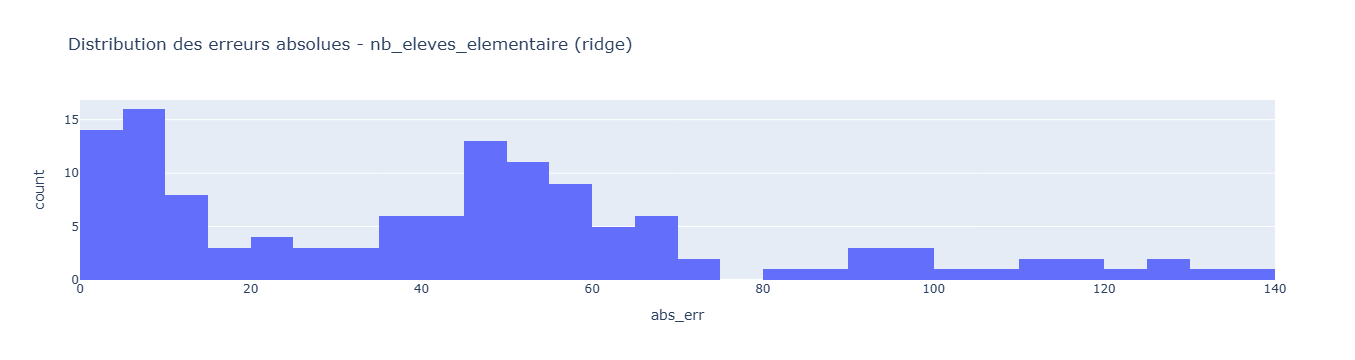

,y_true,y_pred,abs_err
count,128.000000,128.000000,128.000000
mean,352.460938,359.301967,44.454595
std,245.790254,258.684187,34.728890
min,51.000000,72.508521,0.491479
25%,151.500000,202.856818,11.481864
50%,317.500000,298.037972,45.461082
75%,459.500000,423.932779,60.441567
max,897.000000,932.443290,138.364079


In [6]:
from p13.ml.feature_engineering import spatial_train_test_split

target_focus = 'nb_eleves_elementaire'
winner = results[results['target'] == target_focus].sort_values('test_r2', ascending=False).iloc[0]['model']

df_t = df_eng.dropna(subset=feature_cols + [target_focus])
df_train, df_test = spatial_train_test_split(df_t, group_col=SPATIAL_GROUP_COLUMN, test_size=0.2)

model = get_model_candidates()[winner]
model.fit(df_train[feature_cols], df_train[target_focus])
pred = model.predict(df_test[feature_cols])

errors = pd.DataFrame({'y_true': df_test[target_focus].values, 'y_pred': pred})
errors['abs_err'] = (errors['y_true'] - errors['y_pred']).abs()

fig_err = px.histogram(errors, x='abs_err', nbins=30, title=f'Distribution des erreurs absolues - {target_focus} ({winner})')
fig_err.show()
errors.describe()

## Analyse de la distribution des erreurs

L'histogramme montre la répartition des **erreurs absolues** (|ŷ − y|) du meilleur modèle sur `nb_eleves_elementaire`.

**Ce qu'on cherche :**
- Une distribution **concentrée vers 0** → le modèle est précis sur la majorité des communes.
- Une queue longue à droite → quelques communes difficiles à prédire (communes en forte croissance, données atypiques).

**Seuils indicatifs pour ce projet :**
| Erreur absolue | Interprétation opérationnelle |
|---|---|
| < 20 élèves | Excellent — précision suffisante pour planifier 1 classe |
| 20 – 50 élèves | Acceptable — marge d'incertitude à communiquer |
| > 50 élèves | À surveiller — peut impacter l'ouverture/fermeture d'une classe entière |

> Les communes avec les erreurs les plus fortes sont souvent celles qui ont connu un **boom démographique récent** non encore reflété dans les features historiques.

## Diagnostics de la régression linéaire (hypothèses classiques)

La régression linéaire (et Ridge, qui n'est qu'une version régularisée) repose sur plusieurs hypothèses. 
Si elles ne sont pas respectées, le R² peut être trompeur même s'il est élevé. On vérifie ici, pour chaque cible, sur le modèle `statsmodels.OLS` équivalent :

| Test | Hypothèse vérifiée | H0 (hypothèse nulle) | Rejet de H0 si p < 0.05 |
|---|---|---|---|
| **Rainbow** | Adéquation / linéarité de la relation | Le modèle linéaire est correctement spécifié | Signale une relation non-linéaire non capturée |
| **Shapiro-Wilk** | Normalité des résidus | Les résidus suivent une loi normale | Résidus non normaux → IC et p-values des coefficients peu fiables |
| **Breusch-Pagan** | Homoscédasticité | La variance des résidus est constante | Hétéroscédasticité → variance des erreurs dépend du niveau prédit |
| **Distance de Cook** | Effet de levier / points influents | (pas un test statistique — seuil indicatif 4/n) | Points au-delà du seuil pèsent excessivement sur le modèle |
| **Durbin-Watson** | Indépendance des résidus | Pas d'autocorrélation des résidus | DW proche de 2 = OK ; <1.5 ou >2.5 = autocorrélation |

Sources : [Shapiro](https://sites.google.com/site/rgraphiques/4--stat/machine-learning-biostatistiques-analyse-de-donn%C3%A9es/r%C3%A9gressions-lin%C3%A9aires-avec-r#h.p_UkvNLLA1CJQO), [Breusch-Pagan](https://sites.google.com/site/rgraphiques/4--stat/machine-learning-biostatistiques-analyse-de-donn%C3%A9es/r%C3%A9gressions-lin%C3%A9aires-avec-r#h.p_jglvLuXsGrLH), [Distance de Cook](https://sites.google.com/site/rgraphiques/4--stat/machine-learning-biostatistiques-analyse-de-donn%C3%A9es/r%C3%A9gressions-lin%C3%A9aires-avec-r#h.p_vOG28V5qKDT1)

> ⚠️ Note sur le Durbin-Watson : ce test suppose un **ordre naturel** des observations (typiquement temporel). Ici, le dataset mélange 43 communes × 16 rentrées — l'autocorrélation détectée reflétera surtout la dépendance temporelle **au sein de chaque commune**, pas un artefact aléatoire. À interpréter avec cette réserve.

In [7]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_rainbow, het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro

diagnostic_rows = []
ols_models = {}

for target in ALL_TARGETS:
    df_t = df_eng.dropna(subset=feature_cols + [target]).reset_index(drop=True)
    X_sm = sm.add_constant(df_t[feature_cols].values)
    y_sm = df_t[target].values

    ols = sm.OLS(y_sm, X_sm).fit()
    ols_models[target] = ols
    resid = ols.resid

    # 1. Rainbow test — adéquation / linéarité
    rainbow_stat, rainbow_p = linear_rainbow(ols)

    # 2. Shapiro-Wilk — normalité des résidus
    shapiro_stat, shapiro_p = shapiro(resid)

    # 3. Breusch-Pagan — hétéroscédasticité
    bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(resid, X_sm)

    # 4. Distance de Cook — effet de levier
    influence = OLSInfluence(ols)
    cooks_d = influence.cooks_distance[0]
    cook_threshold = 4 / len(y_sm)
    n_influential = int((cooks_d > cook_threshold).sum())

    # 5. Durbin-Watson — indépendance des résidus
    dw_stat = durbin_watson(resid)

    diagnostic_rows.append({
        'target': target,
        'rainbow_stat': round(rainbow_stat, 4), 'rainbow_p': round(rainbow_p, 4),
        'shapiro_stat': round(shapiro_stat, 4), 'shapiro_p': round(shapiro_p, 6),
        'breusch_pagan_p': round(bp_p, 6),
        'n_points_influents_cook': n_influential,
        'pct_points_influents': round(n_influential / len(y_sm) * 100, 1),
        'durbin_watson': round(dw_stat, 3),
    })

df_diag = pd.DataFrame(diagnostic_rows)
df_diag

,target,rainbow_stat,rainbow_p,shapiro_stat,shapiro_p,breusch_pagan_p,n_points_influents_cook,pct_points_influents,durbin_watson
0,nb_eleves_maternelle,1.2529,0.0190,0.8185,0.0,0.0,27,3.9,1.908
1,nb_eleves_elementaire,0.7990,0.9807,0.4865,0.0,0.0,21,3.1,1.978
2,nb_classes,0.6047,1.0000,0.3757,0.0,0.0,15,2.2,2.020


In [8]:
seuil = 0.05

for _, row in df_diag.iterrows():
    print(f"\n{'='*55}\n{row['target']}\n{'='*55}")

    print(f"1. Rainbow (linéarité)      : p={row['rainbow_p']:.4f} → "
          + ("relation non-linéaire suspectée" if row['rainbow_p'] < seuil else "linéarité non rejetée (OK)"))

    print(f"2. Shapiro (normalité)      : p={row['shapiro_p']:.6f} → "
          + ("résidus NON normaux" if row['shapiro_p'] < seuil else "résidus normaux (OK)"))

    print(f"3. Breusch-Pagan (homosc.)  : p={row['breusch_pagan_p']:.6f} → "
          + ("hétéroscédasticité détectée" if row['breusch_pagan_p'] < seuil else "variance constante (OK)"))

    print(f"4. Distance de Cook          : {row['n_points_influents_cook']} points influents "
          f"({row['pct_points_influents']}% des observations, seuil=4/n)")

    dw = row['durbin_watson']
    dw_verdict = "autocorrélation positive" if dw < 1.5 else ("autocorrélation négative" if dw > 2.5 else "indépendance OK")
    print(f"5. Durbin-Watson (indép.)   : DW={dw:.3f} → {dw_verdict}")


nb_eleves_maternelle
1. Rainbow (linéarité)      : p=0.0190 → relation non-linéaire suspectée
2. Shapiro (normalité)      : p=0.000000 → résidus NON normaux
3. Breusch-Pagan (homosc.)  : p=0.000000 → hétéroscédasticité détectée
4. Distance de Cook          : 27 points influents (3.9% des observations, seuil=4/n)
5. Durbin-Watson (indép.)   : DW=1.908 → indépendance OK

nb_eleves_elementaire
1. Rainbow (linéarité)      : p=0.9807 → linéarité non rejetée (OK)
2. Shapiro (normalité)      : p=0.000000 → résidus NON normaux
3. Breusch-Pagan (homosc.)  : p=0.000000 → hétéroscédasticité détectée
4. Distance de Cook          : 21 points influents (3.1% des observations, seuil=4/n)
5. Durbin-Watson (indép.)   : DW=1.978 → indépendance OK

nb_classes
1. Rainbow (linéarité)      : p=1.0000 → linéarité non rejetée (OK)
2. Shapiro (normalité)      : p=0.000000 → résidus NON normaux
3. Breusch-Pagan (homosc.)  : p=0.000000 → hétéroscédasticité détectée
4. Distance de Cook          : 15 points influ

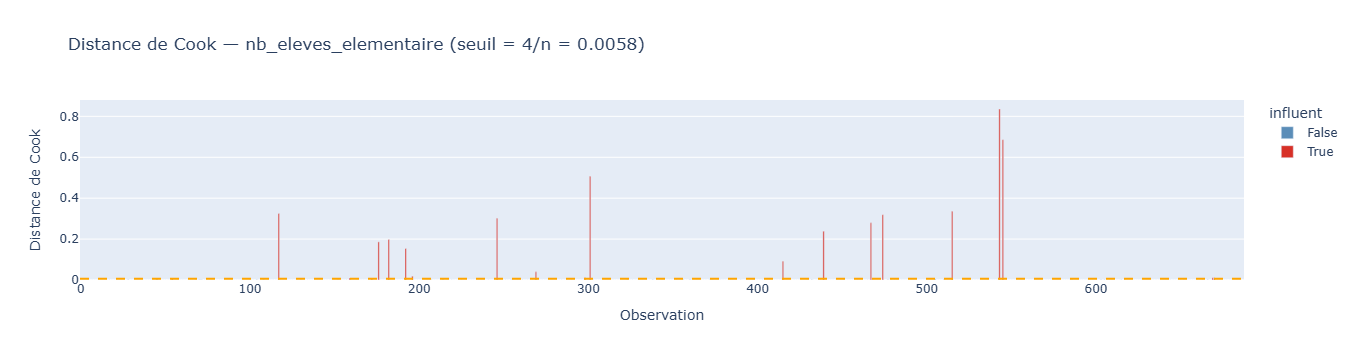

In [9]:
target_diag = target_focus  # réutilise nb_eleves_elementaire défini plus haut

influence = OLSInfluence(ols_models[target_diag])
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)

df_cook = pd.DataFrame({'index': range(len(cooks_d)), 'cooks_d': cooks_d})
df_cook['influent'] = df_cook['cooks_d'] > threshold

fig_cook = px.bar(
    df_cook, x='index', y='cooks_d', color='influent',
    title=f"Distance de Cook — {target_diag} (seuil = 4/n = {threshold:.4f})",
    labels={'cooks_d': 'Distance de Cook', 'index': 'Observation'},
    color_discrete_map={True: '#d73027', False: '#5b8db8'},
)
fig_cook.add_hline(y=threshold, line_dash='dash', line_color='orange')
fig_cook.show()

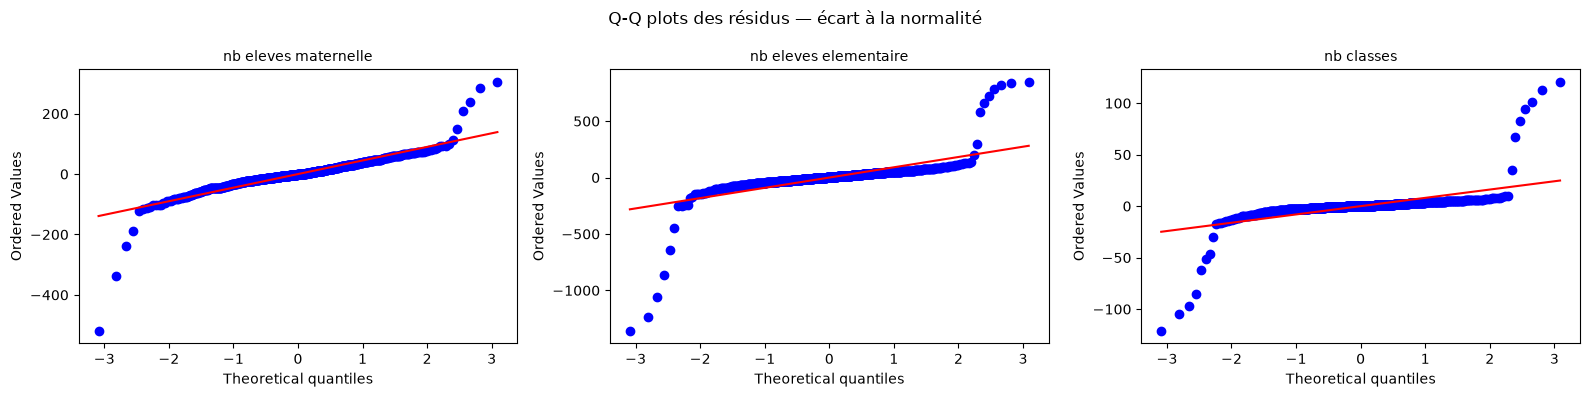

In [10]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, target in zip(axes, ALL_TARGETS):
    resid = ols_models[target].resid
    stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title(target.replace('_', ' '), fontsize=10)
plt.suptitle("Q-Q plots des résidus — écart à la normalité", fontsize=12)
plt.tight_layout()
plt.show()

## Synthèse et recommandation finale

Maintenant qu'on a le tableau complet + les diagnostics, voici la synthèse et ma recommandation.

### 1. Le vrai classement Linear vs Ridge (cellule 5/7)

| Cible | Linear R² | Ridge R² | Écart | test_std |
|---|---|---|---|---|
| Maternelle | 0.9157 | **0.9161** | 0.0004 | 0.043 |
| Élémentaire | 0.9425 | **0.9439** | 0.0014 | 0.037 |
| Classes | **0.9168** | 0.9151 | 0.0017 | 0.047 |

**Conclusion clé :** l'écart entre Linear et Ridge (0.0004 à 0.0017) est 20 à 100 fois plus petit que le `test_std` (0.037 à 0.047). Autrement dit, la différence entre les deux modèles est totalement noyée dans le bruit de la validation spatiale. Ce n'était donc ni un bug, ni un vrai signal — juste deux modèles statistiquement indiscernables sur ce jeu de données. Le "gagnant" affiché par target est un artefact du split.

### 2. Random Forest / Gradient Boosting : à exclure définitivement

Confirmé sans ambiguïté : R² négatifs partout (jusqu'à -6.87), overfit_gap énorme (jusqu'à 7.86). Ces modèles mémorisent les communes vues à l'entraînement mais ne généralisent pas du tout à une commune inconnue. Avec seulement 43 communes, ils n'ont pas assez de diversité pour apprendre une vraie relation généralisable — le texte de votre rapport avait raison de les écarter, même si l'ampleur réelle du problème est bien pire que les "15-20%" annoncés.

### 3. Ce que disent les diagnostics (cellules 12-13)

| Test | Maternelle | Élémentaire | Classes | Impact pratique |
|---|---|---|---|---|
| Rainbow (linéarité) | ⚠️ non-linéarité suspectée | ✅ OK | ✅ OK | Mineur — 1 cible sur 3 |
| Shapiro (normalité résidus) | ❌ non normaux | ❌ non normaux | ❌ non normaux | Affecte les IC/p-values des coefficients, pas la qualité prédictive brute |
| Breusch-Pagan (homoscédasticité) | ❌ hétéroscédasticité | ❌ hétéroscédasticité | ❌ hétéroscédasticité | L'erreur grandit avec la taille de la commune (attendu : 40 à 11 000 élèves) |
| Cook (points influents) | 3.9% | 3.1% | 2.2% | Normal pour ce seuil (4/n), rien d'alarmant |
| Durbin-Watson | 1.91 | 1.98 | 2.02 | ✅ Indépendance OK malgré structure en panel |

L'hétéroscédasticité et la non-normalité sont **cohérentes avec la nature des données** (une commune de 400 élèves et une de 11 000 élèves n'ont pas la même variance d'erreur) — ce n'est pas surprenant, mais ça veut dire que le R² global masque une hétérogénéité : le modèle est probablement plus précis en absolu sur les petites communes que sur les grandes.

### Recommandation finale

**Choisir Ridge pour les 3 cibles**, avec l'alpha tuné par cible (`best_ridge_alphas.json`), plutôt que d'alterner Linear/Ridge selon le "gagnant" du moment.

Pourquoi Ridge plutôt que Linear malgré l'égalité de score :
- Comportement identique en prédiction (écart non significatif)
- Plus robuste si des communes futures ont des valeurs de features extrêmes (la régularisation limite l'explosion des coefficients, contrairement à l'OLS pur)
- Cohérent avec le fait que vos features engineered sont corrélées entre elles (`nb_enfants_0_14` dérive directement de `population`), donc un peu de colinéarité existe — Ridge la gère mieux que la régression linéaire classique

**À documenter dans le rapport, sans bloquer la mise en production :**
- Random Forest/GB écartés (confirmé, plus radicalement que prévu)
- Limites statistiques : hétéroscédasticité et non-normalité des résidus présentes sur les 3 cibles → les intervalles de confiance classiques ne sont pas fiables, mais ça n'invalide pas le R² ni les prédictions ponctuelles
- Piste d'amélioration future (pas urgente) : tester une transformation log de la cible pour stabiliser la variance, ou une régression pondérée (WLS), vu l'hétéroscédasticité confirmée